In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
DB_PATH = "dev.duckdb" if Path("dev.duckdb").exists() else "../dev.duckdb"

Path("charts").mkdir(exist_ok=True)
con = duckdb.connect(DB_PATH, read_only=True)
con.sql("select table_schema, table_name from information_schema.tables order by 1, 2").df()

,table_schema,table_name
0,main,globepay_acceptance_payments
1,main,globepay_chargeback_payments
2,main,globepay_payments
3,main,metricflow_time_spine
4,main,payments__acceptance_rate_over_time
5,main,payments__amounts_over_time
6,main,stg_globepay__acceptance_payments
7,main,stg_globepay__chargeback_payments
8,snapshots,chargeback_payments_snapshot


In [8]:
q1 = con.sql("""
    select
        aggregation_date AS month,
        acceptance_rate_pct,
        acceptance_rate_by_value_pct
    from payments__acceptance_rate_over_time
    where aggregation_filter = 'monthly'
    order by month
""").df()
q1

,month,acceptance_rate_pct,acceptance_rate_by_value_pct
0,2019-01-01,70.0,69.0
1,2019-02-01,70.0,71.0
2,2019-03-01,69.0,69.0
3,2019-04-01,68.0,69.0
4,2019-05-01,69.0,69.0
5,2019-06-01,72.0,71.0


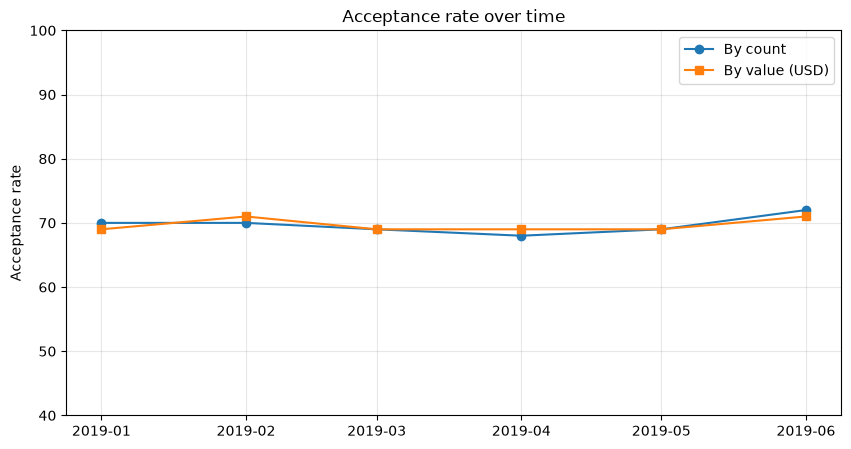

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(q1["month"], q1["acceptance_rate_pct"], marker="o", label="By count")
ax.plot(q1["month"], q1["acceptance_rate_by_value_pct"], marker="s", label="By value (USD)")
ax.set_title("Acceptance rate over time")
ax.set_ylabel("Acceptance rate")
ax.set_ylim(40, 100)
ax.legend()
ax.grid(alpha=0.3)
plt.savefig("charts/acceptance_rate_monthly.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
q2 = con.sql("""
    select
        payment_country,
        sum(declined_payments_amount_in_dollars) AS total_declined_payments_amount_in_dollars
    from payments__amounts_over_time
    group by 1
    order by 2 desc
""").df()
q2

,payment_country,total_declined_payments_amount_in_dollars
0,FR,32626810.31
1,UK,27490178.78
2,AE,26335152.43
3,US,25125669.78
4,CA,18421949.27
5,MX,876157.91


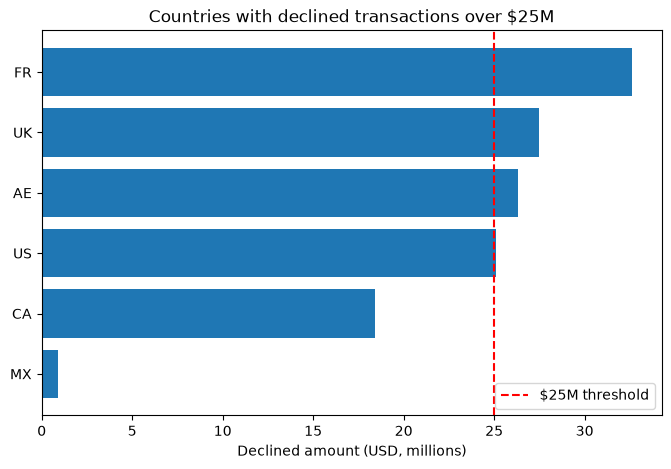

In [18]:
threshold = 25_000_000

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(q2["payment_country"], q2["total_declined_payments_amount_in_dollars"] / 1e6)
ax.axvline(threshold / 1e6, color="red", linestyle="--", label="$25M threshold")
ax.set_xlabel("Declined amount (USD, millions)")
ax.set_title("Countries with declined transactions over $25M")
ax.invert_yaxis()
ax.legend()
plt.savefig("charts/declined_by_country.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
q3 = con.sql("""
select count(*)
from stg_globepay__acceptance_payments acceptance
left join stg_globepay__chargeback_payments chargeback
	on acceptance.globepay_payment_id = chargeback.globepay_payment_id
where chargeback.globepay_payment_id is null
""").df()
q3

,count_star()
0,0
